In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("/content/Patient rating and review.csv",encoding='latin1')

In [5]:
df.shape


(53766, 7)

In [6]:
df.isnull().sum()

,0
uniqueID,0
drugName,0
condition,295
review,0
rating,0
date,0
usefulCount,0


In [7]:
df.isnull().sum()

,0
uniqueID,0
drugName,0
condition,295
review,0
rating,0
date,0
usefulCount,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53766 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   uniqueID     53766 non-null  int64 
 1   drugName     53766 non-null  object
 2   condition    53471 non-null  object
 3   review       53766 non-null  object
 4   rating       53766 non-null  int64 
 5   date         53766 non-null  object
 6   usefulCount  53766 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 2.9+ MB


In [10]:
df.nunique()

,0
uniqueID,53766
drugName,2637
condition,708
review,48280
rating,10
date,3566
usefulCount,325


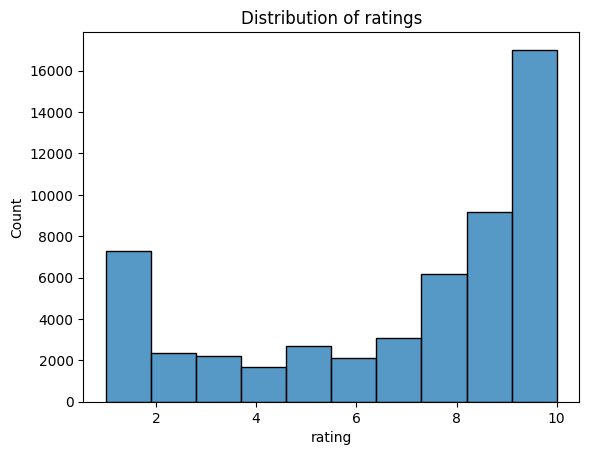

In [11]:
sns.histplot(data=df,x='rating',bins=10)
plt.title('Distribution of ratings')
plt.show()

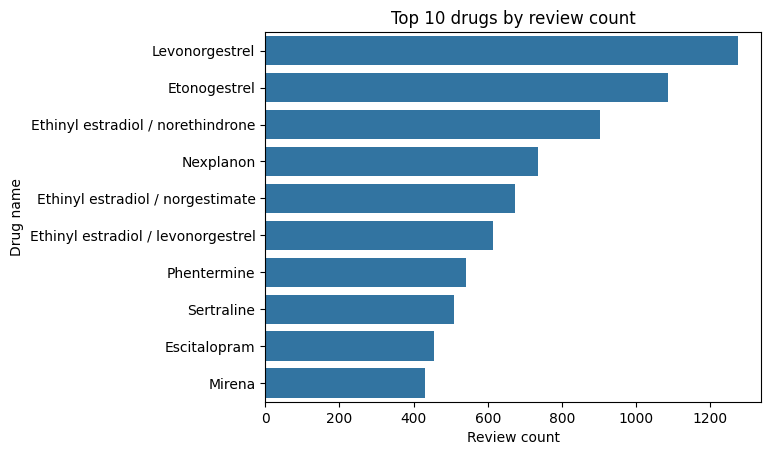

In [12]:
top_drugs=df['drugName'].value_counts().head(10)
sns.barplot(x=top_drugs.values,y=top_drugs.index)
plt.xlabel('Review count')
plt.ylabel('Drug name')
plt.title('Top 10 drugs by review count')
plt.show()

In [13]:
top_drugs

,count
drugName,
Levonorgestrel,1273
Etonogestrel,1085
Ethinyl estradiol / norethindrone,903
Nexplanon,736
Ethinyl estradiol / norgestimate,673
Ethinyl estradiol / levonorgestrel,615
Phentermine,542
Sertraline,508
Escitalopram,455


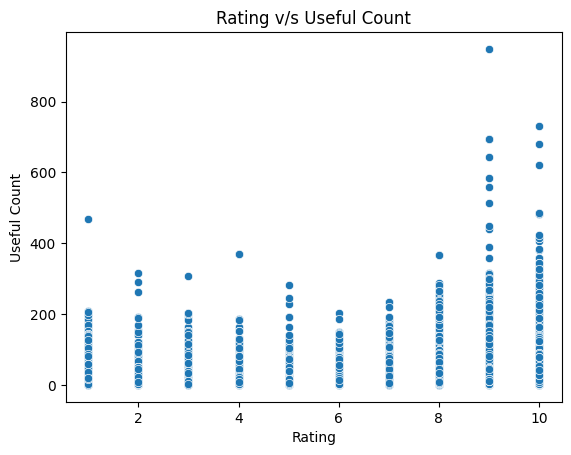

In [14]:
sns.scatterplot(data=df,x='rating',y='usefulCount')
plt.title('Rating v/s Useful Count')
plt.xlabel('Rating')
plt.ylabel('Useful Count')
plt.show()

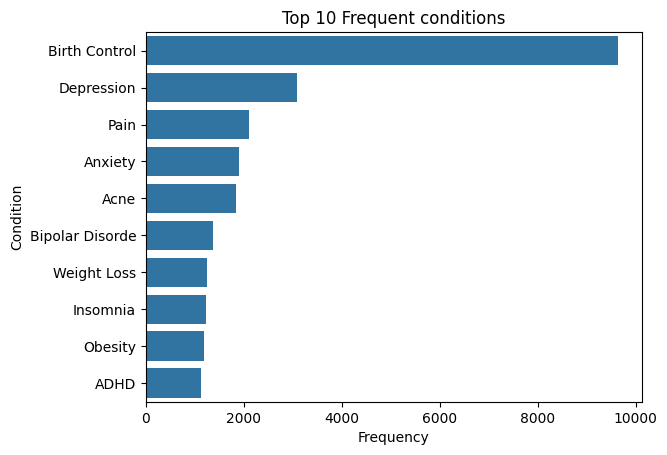

In [15]:
top_conditions=df['condition'].value_counts().head(10)
sns.barplot(x=top_conditions.values,y=top_conditions.index)
plt.title('Top 10 Frequent conditions')
plt.xlabel('Frequency')
plt.ylabel('Condition')
plt.show()

In [16]:
top_conditions

,count
condition,
Birth Control,9648
Depression,3095
Pain,2100
Anxiety,1908
Acne,1847
Bipolar Disorde,1380
Weight Loss,1248
Insomnia,1231
Obesity,1189


In [18]:
def get_medications_for_condition(condition):
  medications = df[df['condition']==condition]['drugName'].unique()
  print(medications)


In [19]:
get_medications_for_condition('Birth Control')

['Cyclafem 1 / 35' 'Copper' 'Levora' 'Blisovi Fe 1 / 20' 'NuvaRing'
 'Aubra' 'Ethinyl estradiol / etonogestrel' 'Microgestin Fe 1.5 / 30'
 'Etonogestrel' 'Ortho Tri-Cyclen Lo' 'Skyla'
 'Ethinyl estradiol / norethindrone' 'ParaGard'
 'Ethinyl estradiol / levonorgestrel' 'Aviane' 'Implanon' 'Levonorgestrel'
 'Ethinyl estradiol / norgestimate' 'Lo Loestrin Fe' 'Yaz' 'Jolessa'
 'Nexplanon' 'Kariva' 'Depo-Provera' 'Safyral'
 'Drospirenone / ethinyl estradiol' 'Microgestin Fe 1 / 20' 'Apri'
 'Ortho Evra' 'Alesse' 'Junel Fe 1 / 20' 'Mirena' 'Tri-Sprintec'
 'Junel Fe 1.5 / 30' 'Chateal' 'Ethinyl estradiol / norelgestromin'
 'Sprintec' 'Mononessa' 'Xulane' 'Desogestrel / ethinyl estradiol' 'Zovia'
 'Ortho Cyclen' 'TriNessa' 'Kyleena' 'Medroxyprogesterone' 'Tri-Previfem'
 'Enskyce' 'Dienogest / estradiol' 'Minastrin 24 Fe' 'Mibelas 24 Fe'
 'Portia' 'Ethinyl estradiol / norgestrel' 'Liletta' 'Ortho Micronor'
 'Yasmin' 'Larin Fe 1.5 / 30' 'Lutera'
 'Drospirenone / ethinyl estradiol / levomefolate 

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
df = df[['drugName', 'condition']]
df.dropna(subset=['condition'], inplace=True)
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['condition'])
user_condition = input("Enter your health condition: ")
user_condition_tfidf = tfidf_vectorizer.transform([user_condition])
similarity_scores = cosine_similarity(user_condition_tfidf, tfidf_matrix)
top_indices = similarity_scores.argsort()[0][::-1]
top_medicines = df['drugName'].iloc[top_indices]
print("Top recommended medicines for", user_condition, ":")
for medicine in top_medicines:
  print(medicine)


/tmp/ipykernel_1243/709543761.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['condition'], inplace=True)


Streaming output truncated to the last 5000 lines.
Metronidazole
Metronidazole
Oxycodone
Lexapro
Miconazole
Fingolimod
Celexa
Januvia
Ethinyl estradiol / norgestimate
Prempro
Tramadol
Alprazolam
Macrobid
Metoprolol Tartrate
Modafinil
Ethinyl estradiol / etonogestrel
Zaleplon
Fluticasone
Phentermine
Divalproex sodium
Propranolol
Hydroxyzine
Ethinyl estradiol / norethindrone
Hydroxyzine
Lorcaserin
Duac
Ethinyl estradiol / norethindrone
Keppra
Plaquenil
Adipex-P
Varenicline
Generess Fe
Golimumab
Omeprazole / sodium bicarbonate
Plan B One-Step
Mirtazapine
Humira
Contrave
Levaquin
Risperdal
Nexplanon
NuvaRing
Contrave
Lyrica
Nuvigil
Kionex
Aripiprazole
Albuterol
Diclofenac
Rabeprazole
Propranolol
Morphine
Citalopram
Vardenafil
Zonisamide
Lithium
Etanercept
Methylphenidate
Lexapro
Oxycodone
Levo-Dromoran
Norvasc
Tikosyn
Valtrex
Magnesium hydroxide
Prozac
Ocella
Tramadol
Avelox
Arcalyst
Keppra
Trulicity
Plan B
Yasmin
Bupropion
Ziprasidone
Lorcaserin
Azithromycin Dose Pack
Contrave
Clindamycin

In [22]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
df = df[['drugName', 'condition']]
df.dropna(subset=['condition'], inplace=True)
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['condition'])